# Final Proje — Dergi Önerisi ve Topic Clustering

**Muharrem Kocabıyık** · Bilgisayar Mühendisliği · **Öğrenci No:** 20210808013

Bu notebook, projedeki **Python adımları (`step1`–`step9`)** ile aynı mantığı özetler; ağır eğitim işleri yine `.py` dosyalarında (tekrarlanabilirlik için).

1. **Adım özeti ve teslim eşlemesi** — aşağıdaki §0.1–0.2  
2. **Veri özeti** — `step5_enriched_dataset.csv` hızlı kontrol  
3. **Açıklama + isteğe bağlı eğitim** — `step8` / `step9` (`subprocess`; kaynak kod değişmez)  
4. **Metrik ve grafikler** — holdout çubukları, küme dağılımı, sınıf sayısı  
5. **Demo** — örnek özet → Top-5; küme raporları (`CLUSTER_IDS_TO_SHOW`)  
6. **Uçtan uca akış** — genişletilmiş mermaid diyagram  

> `step8` tam veriyle uzun sürebilir. `journal_recommender_pipeline.pkl` ve `step9_clustered_dataset.csv` hazırsa eğitim hücrelerini atlayabilirsiniz.

## 0) Ortam

- Notebook’u proje **kök klasöründe** açın (`final_project`).  
- Paketler: `requirements.txt` — tipik olarak `pandas`, `numpy`, `scikit-learn`, `joblib`, `matplotlib`.  
- Ham veri: `!sources/CompSciencePub.sqlite` (yol `step5` / `step1.1` script’lerinde kullanılır).  
- Bu notebook’un eğitim hücreleri için: **`step5_enriched_dataset.csv`** gerekli (önce `step5_enrich_dataset.py` çalıştırılmalı).  
- `step9_topic_clustering.py` içindeki çıktı yolu kendi makinenize uygun olmalı.  
- Tüm adımların metin açıklaması: **`PROJE_DOKUMANTASYONU.md`**

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

%matplotlib inline
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("ggplot")
    except OSError:
        pass

ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dashboard.clusters_meta import get_cluster_keywords, infer_cluster_name
from dashboard.config import CLUSTERED_DATA_PATH, PIPELINE_PATH, RECOMMENDER_META_PATH
from dashboard.recommender_logic import recommend_journals

print("Proje kökü:", ROOT)

Proje kökü: D:\FourthYear_2\3-Introduction_to_Data_Mining\final_project


### 0.1) Teslim / çıktı eşlemesi

| Beklenen çıktı | Bu projede |
|----------------|------------|
| Kaynak kod | `step1.py` … `step9_*.py`, `dashboard/`, `app.py` |
| Jupyter | Bu dosya (`20210808013_Final_Project.ipynb`) |
| IEEE rapor | `IEEE_PROJECT_REPORT.tex` |
| Özet → Top-5 dergi | `step8_final_recommender.py` → `journal_recommender_pipeline.pkl` + `journal_recommender_meta.json`; canlı demo: `py -m streamlit run app.py` |
| Konu kümeleri | `step9_topic_clustering.py` → `step9_clustered_dataset.csv` |

### 0.2) Step 1–9 — script ve ara çıktılar

| Adım | Script | Ana çıktı / amaç |
|------|--------|------------------|
| 1 | `step1.py` | SQLite tablo keşfi |
| 1.1 | `step1.1.py` | `step1_basic_joined_dataset.csv` |
| 2 | `step2.py` | `step2_preprocessed_dataset.csv` (metin temizliği) |
| 3 | `step3_baseline.py` | TF-IDF + kosinüs **retrieval** baseline (sınıflandırıcı değil) |
| 4 | `step4_compare_texts.py` | Farklı metin alanlarının retrieval kalitesi karşılaştırması |
| 5 | `step5_enrich_dataset.py` | `step5_enriched_dataset.csv` (keyword, keyword+, subject) |
| 6 | `step6_compare_rich_text.py` | `text_title_abstract` vs **`text_rich`** karşılaştırması |
| 7 | `step7_logreg_baseline.py` | TF-IDF + Logistic Regression (tek sütun referans) |
| 8 | `step8_final_recommender.py` | Dört kanallı `ColumnTransformer` + `SGDClassifier` → **final pipeline** |
| 9 | `step9_topic_clustering.py` | TF-IDF + KMeans → `step9_clustered_dataset.csv` |

**Önerilen sıra (sıfırdan):** `step1.1` → `step2` → `step5` → (isteğe bağlı `step3`–`7`) → `step8` → `step9`.

*Bu notebook’ta yalnızca §1 veri önizlemesi, §2–3 `step8`/`step9` çalıştırma ve sonuç görselleri yer alır; `step3`–`7` terminalden çalıştırılıp rapora konabilir.*

## 1) Veri seti hızlı kontrol (`step5_enriched_dataset.csv`)

İlk **N** satır okunur (tam dosya büyük olabilir). `step8` / `step9` bu CSV'den beslenir.

In [2]:
STEP5_PATH = ROOT / "step5_enriched_dataset.csv"
PREVIEW_ROWS = 15_000

if not STEP5_PATH.is_file():
    display(Markdown("**Uyarı:** `step5_enriched_dataset.csv` yok."))
else:
    df5 = pd.read_csv(STEP5_PATH, nrows=PREVIEW_ROWS)
    display(Markdown(f"**Önizleme:** en fazla **{PREVIEW_ROWS:,}** satır."))
    print("Sütun:", df5.shape[1], "| Satır (önizleme):", df5.shape[0])
    if "JournalName" in df5.columns:
        print("Benzersiz dergi (önizleme):", df5["JournalName"].nunique())
    display(df5.head(2))
    del df5


**Önizleme:** en fazla **15,000** satır.

Sütun: 17 | Satır (önizleme): 15000
Benzersiz dergi (önizleme): 315


,AcademicRecordID,Title,AbstractText,PublicationId,JournalName,PubYear,keywords_text,keyword_plus_text,subjects_text,title_clean,abstract_clean,keywords_clean,keyword_plus_clean,subjects_clean,text_title_abstract,text_rich,rich_word_count
0,88652,An updated survey of GA-based multiobjective o...,<p>After using evolutionary techniques for sin...,11050,ACM COMPUTING SURVEYS,2000,algorithms artificial intelligence genetic alg...,GENETIC ALGORITHM MULTICRITERIA OPTIMIZATION S...,"Computer Science, Theory & Methods Computer Sc...",an updated survey of ga based multiobjective o...,after using evolutionary techniques for single...,algorithms artificial intelligence genetic alg...,genetic algorithm multicriteria optimization s...,computer science theory methods computer science,an updated survey of ga based multiobjective o...,an updated survey of ga based multiobjective o...,191
1,88653,The state of the art in distributed query proc...,<p>Distributed data processing is becoming a r...,11050,ACM COMPUTING SURVEYS,2000,query optimization query execution client-serv...,DATABASE-SYSTEMS DATA REPLICATION PERFORMANCE ...,"Computer Science, Theory & Methods Computer Sc...",the state of the art in distributed query proc...,distributed data processing is becoming a real...,query optimization query execution client serv...,database systems data replication performance ...,computer science theory methods computer science,the state of the art in distributed query proc...,the state of the art in distributed query proc...,272


## 2) Journal recommendation — `step8_final_recommender.py` ne yapıyor?

**Girdi:** `step5_enriched_dataset.csv`  
**Filtreler:** `JournalName` ve `abstract_clean` dolu; dergi başına en az **5** makale; özet **≥ 20** kelime.  
**Özellikler:** `build_feature_frame` ile dört kanal (`title_channel`, `abstract_channel`, `keywords_channel`, `subjects_channel`); her kanal için ayrı `TfidfVectorizer`; `ColumnTransformer` + `Pipeline` + `SGDClassifier(loss="log_loss")`.

**Train / test:** `train_test_split(..., test_size=0.2, random_state=42, stratify=y)` → **%80 eğitim, %20 tutulmuş (holdout) test**.  
**Metrikler:** Test kümesinde **Top-1 accuracy** (`predict` ile) ve **Top-5 accuracy** (`predict_proba` ile gerçek dergi ilk 5 içinde mi?).  
**Son adım:** Metriklerden sonra pipeline **tüm filtreli veri** üzerinde tekrar eğitilir; `journal_recommender_pipeline.pkl` ve `journal_recommender_meta.json` yazılır.

Aşağıdaki hücre, bu süreci **değiştirmeden** aynı Python dosyasını çalıştırır.

In [3]:
# True yapın: step8 tam eğitim + değerlendirme + .pkl/meta üretir (uzun sürebilir).
RUN_STEP8 = True

step8_script = ROOT / "step8_final_recommender.py"
if not step8_script.is_file():
    raise FileNotFoundError(step8_script)

if RUN_STEP8:
    print("Çalışıyor:", step8_script.name, "…")
    proc = subprocess.run(
        [sys.executable, str(step8_script)],
        cwd=str(ROOT),
        capture_output=False,
        text=True,
    )
    if proc.returncode != 0:
        raise RuntimeError(f"step8 çıkış kodu: {proc.returncode}")
    print("step8 tamam.")
else:
    print("RUN_STEP8=False — atlandı. Eğitim için RUN_STEP8=True yapın veya terminalde: py step8_final_recommender.py")

Çalışıyor: step8_final_recommender.py …
step8 tamam.


## 3) Topic clustering — `step9_topic_clustering.py` ne yapıyor?

**Denetimli train/test yok:** Bu bölüm **gözetimsiz** kümelemedir; tüm (filtrelenmiş) makaleler üzerinde model uyar.

**Girdi:** `step5` CSV’den `AcademicRecordID`, `JournalName`, `text_rich`; dergi başına ≥5 örnek filtresi.  
**Vektör:** `TfidfVectorizer` (İngilizce stop-word, `max_features=5000`, `ngram_range=(1,2)`, `min_df=3`).  
**Kümeleme:** `KMeans(n_clusters=10, random_state=42, n_init=10)` → `fit_predict`.  
**Çıktı:** Konsolda küme başına terimler ve dergi dağılımları; dosya: `step9_clustered_dataset.csv`.

Aşağıdaki hücre aynı script’i çalıştırır.

In [4]:
RUN_STEP9 = True

step9_script = ROOT / "step9_topic_clustering.py"
if not step9_script.is_file():
    raise FileNotFoundError(step9_script)

if RUN_STEP9:
    print("Çalışıyor:", step9_script.name, "…")
    proc = subprocess.run(
        [sys.executable, str(step9_script)],
        cwd=str(ROOT),
        capture_output=False,
        text=True,
    )
    if proc.returncode != 0:
        raise RuntimeError(f"step9 çıkış kodu: {proc.returncode}")
    print("step9 tamam.")
else:
    print("RUN_STEP9=False — atlandı. Küme CSV üretmek için RUN_STEP9=True veya: py step9_topic_clustering.py")

Çalışıyor: step9_topic_clustering.py …
step9 tamam.


## 4) Holdout metrik özeti (`journal_recommender_meta.json`)

Bu dosya **yalnızca `step8` başarıyla bittikten sonra** güncellenir. Tablo sonrası Top-1 / Top-5 çubuk grafiği çizilir.

n_articles                 22966.000000
n_journals                   406.000000
min_words_abstract            20.000000
min_samples_per_journal        5.000000
holdout_test_size              0.200000
holdout_random_state          42.000000
train_n_samples            18372.000000
train_top1_accuracy            0.946168
train_top5_accuracy            0.991727
test_n_samples              4594.000000
holdout_top1_accuracy          0.663474
holdout_top5_accuracy          0.911406
Name: değer, dtype: float64

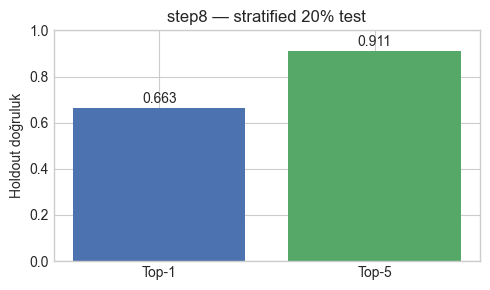

In [5]:
if RECOMMENDER_META_PATH.is_file():
    meta = json.loads(RECOMMENDER_META_PATH.read_text(encoding="utf-8"))
    display(pd.Series(meta, name="değer"))
    t1 = meta.get("holdout_top1_accuracy")
    t5 = meta.get("holdout_top5_accuracy")
    if t1 is not None and t5 is not None:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.bar(["Top-1", "Top-5"], [t1, t5], color=["#4c72b0", "#55a868"])
        ax.set_ylim(0, 1)
        ax.set_ylabel("Holdout doğruluk")
        ax.set_title("step8 — stratified 20% test")
        for i, v in enumerate([t1, t5]):
            ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
        plt.tight_layout()
        plt.show()
else:
    display(Markdown("`journal_recommender_meta.json` yok — önce `step8` çalıştırın."))

## 5) Kayıtlı model ve küme verisi

Pipeline’daki dergi sınıfı sayısı, örnek satırlar ve **küme dağılımı** grafiği.

Yüklü pipeline — dergi sınıfı: 406
Küme CSV shape: (22980, 4)


,AcademicRecordID,JournalName,text_rich,cluster
0,88652,ACM COMPUTING SURVEYS,an updated survey of ga based multiobjective o...,4
1,88653,ACM COMPUTING SURVEYS,the state of the art in distributed query proc...,3


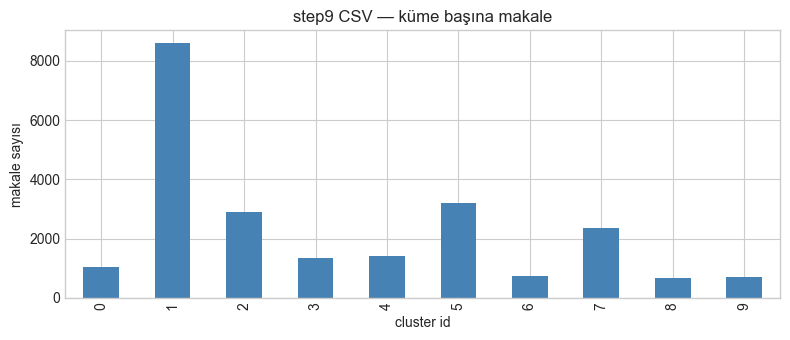

In [6]:
if not PIPELINE_PATH.is_file():
    raise FileNotFoundError(
        f"{PIPELINE_PATH} yok — step8 çalıştırın (RUN_STEP8 veya py step8_final_recommender.py)."
    )
if not CLUSTERED_DATA_PATH.is_file():
    raise FileNotFoundError(
        f"{CLUSTERED_DATA_PATH} yok — step9 çalıştırın (RUN_STEP9 veya py step9_topic_clustering.py)."
    )

pipeline = joblib.load(PIPELINE_PATH)
cluster_df = pd.read_csv(CLUSTERED_DATA_PATH)
n_classes = len(pipeline.named_steps["clf"].classes_)
print(f"Yüklü pipeline — dergi sınıfı: {n_classes}")
print("Küme CSV shape:", cluster_df.shape)
display(cluster_df.head(2))
cc = cluster_df["cluster"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 3.5))
cc.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("cluster id")
ax.set_ylabel("makale sayısı")
ax.set_title("step9 CSV — küme başına makale")
plt.tight_layout()
plt.show()

## 6) Örnek abstract’lar → Top-5 dergi

Tablo + her senaryoda **1. sıradaki** önerinin olasılığı (yatay çubuk).

,Senaryo,Sıra,Dergi,Olasılık
0,Veri madenciliği / sınıflandırma,1,DATA MINING AND KNOWLEDGE DISCOVERY,0.003722
1,Veri madenciliği / sınıflandırma,2,INTELLIGENT DATA ANALYSIS,0.003647
2,Veri madenciliği / sınıflandırma,3,VLDB JOURNAL,0.003524
3,Veri madenciliği / sınıflandırma,4,KNOWLEDGE AND INFORMATION SYSTEMS,0.003279
4,Veri madenciliği / sınıflandırma,5,ACM TRANSACTIONS ON KNOWLEDGE DISCOVERY FROM DATA,0.003183
5,Bilgisayarlı görü / derin öğrenme,1,JOURNAL OF REAL-TIME IMAGE PROCESSING,0.003750
6,Bilgisayarlı görü / derin öğrenme,2,NEURAL PROCESSING LETTERS,0.003658
7,Bilgisayarlı görü / derin öğrenme,3,ACM TRANSACTIONS ON GRAPHICS,0.003303
8,Bilgisayarlı görü / derin öğrenme,4,VISUAL COMPUTER,0.003266
9,Bilgisayarlı görü / derin öğrenme,5,MULTIMEDIA SYSTEMS,0.003244


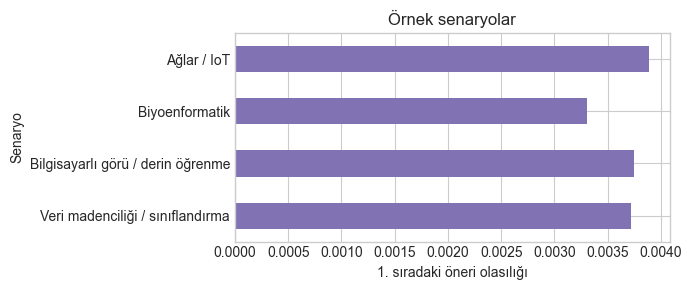

In [7]:
SAMPLE_ABSTRACTS = {
    "Veri madenciliği / sınıflandırma": """
We propose a scalable framework for knowledge discovery from large relational and text databases.
Our method combines frequent pattern mining, feature selection, and ensemble classification.
Experiments on benchmark datasets show improved F1 compared to baseline methods.
""".strip(),
    "Bilgisayarlı görü / derin öğrenme": """
This paper presents a convolutional neural network for real-time object detection in video.
We introduce a lightweight backbone and multi-scale feature fusion with competitive mAP.
""".strip(),
    "Biyoenformatik": """
We develop an algorithm for aligning short reads to a reference genome under noisy sequencing.
The approach uses probabilistic base quality scores and improves variant calling sensitivity.
""".strip(),
    "Ağlar / IoT": """
We study routing and energy efficiency in wireless sensor networks with intermittent connectivity.
A distributed clustering protocol extends network lifetime compared to LEACH-style baselines.
""".strip(),
}

rows = []
for scenario, abstract in SAMPLE_ABSTRACTS.items():
    for rank, r in enumerate(
        recommend_journals(pipeline, abstract=abstract, title="", keywords="", subjects="", top_k=5),
        start=1,
    ):
        rows.append(
            {
                "Senaryo": scenario,
                "Sıra": rank,
                "Dergi": r["journal"],
                "Olasılık": round(r["score"], 6),
            }
        )
rec_df = pd.DataFrame(rows)
display(rec_df)
top1_per = rec_df[rec_df["Sıra"] == 1].set_index("Senaryo")["Olasılık"]
fig, ax = plt.subplots(figsize=(7, 3))
top1_per.plot(kind="barh", ax=ax, color="#8172b3")
ax.set_xlabel("1. sıradaki öneri olasılığı")
ax.set_title("Örnek senaryolar")
plt.tight_layout()
plt.show()

## 7) Topic clusters — örnekler

`CLUSTER_IDS_TO_SHOW = None` tüm kümeler; örn. `[0, 2, 3, 6]` ile daraltın. Tema: `dashboard/clusters_meta.py`.

In [8]:
def cluster_report(cdf: pd.DataFrame, cluster_id: int, n_journals: int = 5, n_samples: int = 2, seed: int = 42):
    sub = cdf[cdf["cluster"] == cluster_id]
    display(Markdown(f"### Küme `{cluster_id}` — *{infer_cluster_name(cluster_id)}*"))
    display(
        Markdown("**Örnek anahtar kelimeler (meta):** " + ", ".join(get_cluster_keywords(cluster_id)))
    )
    display(Markdown(f"**Makale sayısı:** {len(sub):,}"))
    display(sub["JournalName"].value_counts().head(n_journals).rename("adet").to_frame())
    samp = sub.sample(min(n_samples, len(sub)), random_state=seed)[
        ["AcademicRecordID", "JournalName", "text_rich"]
    ]
    prev = samp["text_rich"].astype(str).str.replace(r"\s+", " ", regex=True).str.slice(0, 280)
    tail = np.where(samp["text_rich"].astype(str).str.len() > 280, "…", "")
    out = samp.assign(text_rich_preview=prev + tail)
    display(out[["AcademicRecordID", "JournalName", "text_rich_preview"]])
    display(Markdown("---"))


CLUSTER_IDS_TO_SHOW = None  # örn: [0, 2, 3, 6] — çıktıyı kısaltmak için

ids = sorted(cluster_df["cluster"].unique())
if CLUSTER_IDS_TO_SHOW is not None:
    ids = [i for i in CLUSTER_IDS_TO_SHOW if i in ids]
for cid in ids:
    cluster_report(cluster_df, int(cid))

### Küme `0` — *Cloud Computing and Web Services*

**Örnek anahtar kelimeler (meta):** cloud, service, computing, web, iot

**Makale sayısı:** 1,038

,adet
JournalName,
INTERNATIONAL JOURNAL OF WEB SERVICES RESEARCH,35
IEEE TRANSACTIONS ON SERVICES COMPUTING,31
INTERNATIONAL JOURNAL OF WEB AND GRID SERVICES,28
JOURNAL OF NETWORK AND COMPUTER APPLICATIONS,27
JOURNAL OF GRID COMPUTING,22


,AcademicRecordID,JournalName,text_rich_preview
5634,94555,COMPUTER SYSTEMS SCIENCE AND ENGINEERING,autoscaling scientific workflows on the cloud ...
20018,109453,PERFORMANCE EVALUATION,modeling and performance analysis of cloudlet ...


...

**Örnek anahtar kelimeler (meta):** sensor, wireless sensor, nodes, network, wsn

**Makale sayısı:** 704

,adet
JournalName,
ACM TRANSACTIONS ON SENSOR NETWORKS,46
INTERNATIONAL JOURNAL OF DISTRIBUTED SENSOR NETWORKS,37
INTERNATIONAL JOURNAL OF SENSOR NETWORKS,30
AD HOC & SENSOR WIRELESS NETWORKS,29
WIRELESS NETWORKS,26


,AcademicRecordID,JournalName,text_rich_preview
9573,98894,IEEE TRANSACTIONS ON COMPUTERS,efficient data gathering with mobile collector...
1731,90400,AD HOC NETWORKS,an energy aware distributed clustering protoco...


---

## 8) Proje veri akışı (uçtan uca)

```mermaid
flowchart TB
  DB[(CompSciencePub.sqlite)]
  DB --> S11[step1.1.py]
  S11 --> CSV1[step1_basic_joined_dataset.csv]
  CSV1 --> S2[step2.py]
  S2 --> CSV2[step2_preprocessed_dataset.csv]
  CSV2 --> S35[step3–4 opsiyonel]
  DB --> S5[step5_enrich_dataset.py]
  S5 --> CSV5[step5_enriched_dataset.csv]
  CSV5 --> S68[step6–7 opsiyonel]
  CSV5 --> S8[step8_final_recommender.py]
  S8 --> PKL[journal_recommender_pipeline.pkl]
  S8 --> META[journal_recommender_meta.json]
  CSV5 --> S9[step9_topic_clustering.py]
  S9 --> CLU[step9_clustered_dataset.csv]
  PKL --> UI[Streamlit app.py / notebook demo]
  META --> UI
  CLU --> UI
```

- **Baseline / karşılaştırma:** `step3_baseline`, `step4_compare_texts`, `step6_compare_rich_text`, `step7_logreg_baseline` — rapor ve tekrarlanabilirlik için terminalden; bu notebook’ta çalıştırılmıyor.  
- **Arayüz:** `py -m streamlit run app.py`

---

**Özet:** Holdout train/test yalnızca **`step8_final_recommender.py`** içinde; **`step9`** gözetimsiz kümelemedir. Grafikler `matplotlib` ile üretilir. Eğitim bu notebook’taki `RUN_STEP8` / `RUN_STEP9` bayraklarıyla veya doğrudan terminalden `python step8_final_recommender.py` / `python step9_topic_clustering.py` ile yapılabilir. Adım açıklamaları için **`PROJE_DOKUMANTASYONU.md`** dosyasına bakın.